In [1]:
%pip install pandas numpy matplotlib seaborn scipy sqlalchemy pyodbc

Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install pandas numpy matplotlib seaborn scipy sqlalchemy pyodbc

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sqlalchemy import create_engine

# SQL Server connection 
connection_string = (
    r"mssql+pyodbc://DESKTOP-2QJI1TF\SQLEXPRESS/HRAttritionDB"
    r"?driver=ODBC+Driver+17+for+SQL+Server"
)
engine = create_engine(connection_string)

query = "SELECT * FROM hr_clean"
df = pd.read_sql(query, engine)
print(df.shape)
print(df.dtypes)


Note: you may need to restart the kernel to use updated packages.
(1470, 40)
EmployeeNumber              int64
Age                         int64
AgeGroup                      str
Gender                        str
MaritalStatus                 str
Department                    str
JobRole                       str
JobLevel                    int64
BusinessTravel                str
EducationField                str
Education                   int64
JobSatisfaction             int64
JobSatisfactionLabel          str
EnvironmentSatisfaction     int64
RelationshipSatisfaction    int64
WorkLifeBalance             int64
JobInvolvement              int64
PerformanceRating           int64
MonthlyIncome               int64
SalaryBand                    str
DailyRate                   int64
HourlyRate                  int64
MonthlyRate                 int64
PercentSalaryHike           int64
StockOptionLevel            int64
OverTime                      str
OverTimeFlag                int64
Dista

In [ ]:
# Overall attrition rate
print(df['Attrition'].value_counts(normalize=True).round(3))

# Attrition rate by overtime
overtime_table = df.groupby('OverTime')['AttritionFlag'].agg(['mean','count'])
overtime_table.columns = ['Attrition_Rate', 'Headcount']
overtime_table['Attrition_Rate'] = overtime_table['Attrition_Rate'].round(3)
print(overtime_table)

# Point-biserial correlation: key drivers vs AttritionFlag
numeric_cols = [
    'MonthlyIncome', 'OverTimeFlag', 'JobSatisfaction',
    'WorkLifeBalance', 'Age', 'YearsAtCompany',
    'EnvironmentSatisfaction', 'DistanceFromHome',
    'NumCompaniesWorked', 'TotalWorkingYears'
]
correlations = {}
for col in numeric_cols:
    r, p = stats.pointbiserialr(df[col], df['AttritionFlag'])
    correlations[col] = {'r': round(r,3), 'p_value': round(p,4)}

corr_df = pd.DataFrame(correlations).T.sort_values('r')
print(corr_df)


Attrition
No     0.839
Yes    0.161
Name: proportion, dtype: float64
          Attrition_Rate  Headcount
OverTime                           
No                 0.104       1054
Yes                0.305        416
                             r  p_value
TotalWorkingYears       -0.171   0.0000
MonthlyIncome           -0.160   0.0000
Age                     -0.159   0.0000
YearsAtCompany          -0.134   0.0000
EnvironmentSatisfaction -0.103   0.0001
JobSatisfaction         -0.103   0.0001
WorkLifeBalance         -0.064   0.0142
NumCompaniesWorked       0.043   0.0955
DistanceFromHome         0.078   0.0028
OverTimeFlag             0.246   0.0000


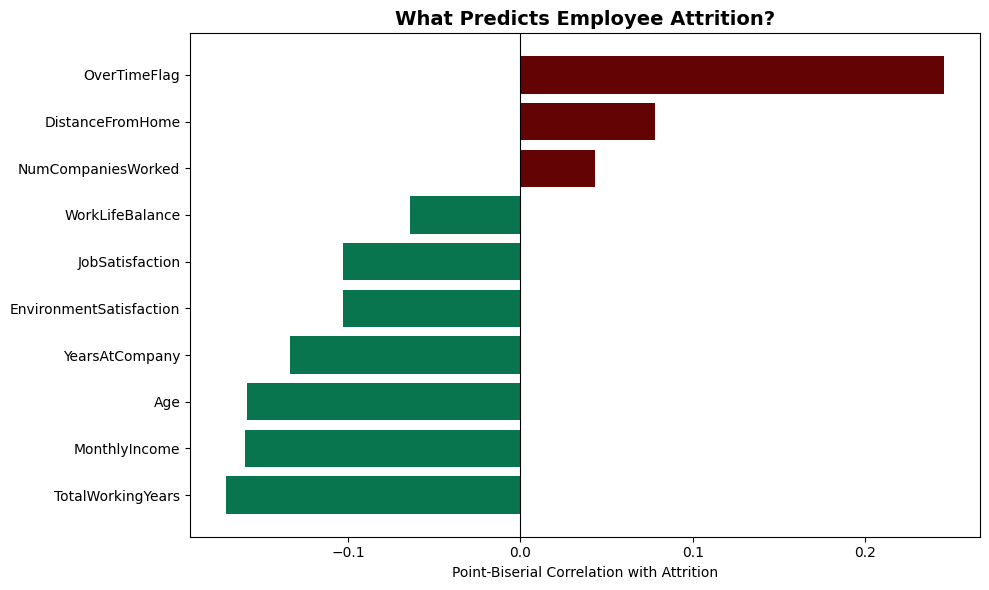

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#640303" if r > 0 else "#09754F" for r in corr_df['r']]
ax.barh(corr_df.index, corr_df['r'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-Biserial Correlation with Attrition')
ax.set_title('What Predicts Employee Attrition?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('attrition_correlations.png', dpi=150)
plt.show()
